# Show, Attend and Tell: Exact Hard-Attention Reproduction
This notebook implements the Stochastic Hard-Attention architecture and REINFORCE training loop as published in the original 2015 ICML paper *Show, Attend and Tell*.

In [1]:
!pip install spacy -q
!python -m spacy download en_core_web_sm -q

import os
import pandas as pd
import spacy
import torch
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from tqdm.notebook import tqdm
import nltk
from nltk.translate.bleu_score import corpus_bleu
from nltk.translate.meteor_score import meteor_score
from collections import defaultdict
import numpy as np
import gc

nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
spacy_eng = spacy.load("en_core_web_sm")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 53.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Using device: cuda


In [2]:
class Vocabulary:
    def __init__(self, freq_threshold):
        self.itos = {0: "<PAD>", 1: "<SOS>", 2: "<EOS>", 3: "<UNK>"}
        self.stoi = {"<PAD>": 0, "<SOS>": 1, "<EOS>": 2, "<UNK>": 3}
        self.freq_threshold = freq_threshold

    def __len__(self):
        return len(self.itos)

    @staticmethod
    def tokenizer_eng(text):
        return [tok.text.lower() for tok in spacy_eng.tokenizer(str(text))]

    def build_vocabulary(self, sentence_list):
        frequencies = {}
        idx = 4
        for sentence in sentence_list:
            for word in self.tokenizer_eng(sentence):
                if word not in frequencies:
                    frequencies[word] = 1
                else:
                    frequencies[word] += 1
                if frequencies[word] == self.freq_threshold:
                    self.stoi[word] = idx
                    self.itos[idx] = word
                    idx += 1

    def numericalize(self, text):
        tokenized_text = self.tokenizer_eng(text)
        return [
            self.stoi[token] if token in self.stoi else self.stoi["<UNK>"]
            for token in tokenized_text
        ]

In [3]:
class FlickrDataset(Dataset):
    def __init__(self, root_dir, df, transform=None, vocab=None):
        self.root_dir = root_dir
        self.df = df
        
        if 'image' in self.df.columns:
            self.imgs = self.df["image"].values
        elif 'image_name' in self.df.columns:
            self.imgs = self.df["image_name"].values
            
        if 'caption' in self.df.columns:
            self.captions = self.df["caption"].astype(str).values
        elif 'comment' in self.df.columns:
            self.captions = self.df["comment"].astype(str).values
            
        self.transform = transform
        self.vocab = vocab

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        caption = self.captions[index]
        img_id = self.imgs[index].strip()
        img_path = os.path.join(self.root_dir, img_id)
        
        img = Image.open(img_path).convert("RGB")
        if self.transform is not None:
            img = self.transform(img)

        numericalized_caption = [self.vocab.stoi["<SOS>"]]
        numericalized_caption += self.vocab.numericalize(caption)
        numericalized_caption.append(self.vocab.stoi["<EOS>"])

        return img, torch.tensor(numericalized_caption), img_id

class MyCollate:
    def __init__(self, pad_idx):
        self.pad_idx = pad_idx

    def __call__(self, batch):
        imgs = [item[0].unsqueeze(0) for item in batch]
        imgs = torch.cat(imgs, dim=0)
        targets = [item[1] for item in batch]
        targets = pad_sequence(targets, batch_first=True, padding_value=self.pad_idx)
        img_ids = [item[2] for item in batch]
        return imgs, targets, img_ids

def prepare_datasets(root_folder, annotation_file, transform, freq_threshold=5):
    df = pd.read_csv(annotation_file, sep=',', engine='python', on_bad_lines='skip')
    df.columns = df.columns.str.strip().str.lower()
    
    img_col = 'image' if 'image' in df.columns else 'image_name'
    cap_col = 'caption' if 'caption' in df.columns else 'comment'
    
    unique_imgs = df[img_col].unique()
    train_imgs = set(unique_imgs[:29000])
    val_imgs = set(unique_imgs[29000:30000])
    test_imgs = set(unique_imgs[30000:31000]) 
    
    train_df = df[df[img_col].isin(train_imgs)]
    val_df = df[df[img_col].isin(val_imgs)]
    test_df = df[df[img_col].isin(test_imgs)]
    
    vocab = Vocabulary(freq_threshold)
    vocab.build_vocabulary(train_df[cap_col].astype(str).tolist())
    
    train_dataset = FlickrDataset(root_folder, train_df, transform=transform, vocab=vocab)
    val_dataset = FlickrDataset(root_folder, val_df, transform=transform, vocab=vocab)
    test_dataset = FlickrDataset(root_folder, test_df, transform=transform, vocab=vocab)
    
    return train_dataset, val_dataset, test_dataset

In [4]:
class EncoderCNN_VGG(nn.Module):
    def __init__(self, encoded_image_size=14):
        super(EncoderCNN_VGG, self).__init__()
        self.enc_image_size = encoded_image_size
        vgg = models.vgg19(weights=models.VGG19_Weights.DEFAULT)
        modules = list(vgg.features.children())[:-1] 
        self.vgg = nn.Sequential(*modules)
        self.adaptive_pool = nn.AdaptiveAvgPool2d((encoded_image_size, encoded_image_size))

    def forward(self, images):
        features = self.vgg(images) 
        features = self.adaptive_pool(features)
        features = features.permute(0, 2, 3, 1) 
        return features

class HardAttention(nn.Module):
    def __init__(self, encoder_dim, decoder_dim, attention_dim):
        super(HardAttention, self).__init__()
        self.encoder_att = nn.Linear(encoder_dim, attention_dim)
        self.decoder_att = nn.Linear(decoder_dim, attention_dim)
        self.full_att = nn.Linear(attention_dim, 1)
        self.relu = nn.ReLU()
        self.softmax = nn.Softmax(dim=1)

    def forward(self, encoder_out, decoder_hidden):
        att1 = self.encoder_att(encoder_out) 
        att2 = self.decoder_att(decoder_hidden) 
        att = self.full_att(self.relu(att1 + att2.unsqueeze(1))).squeeze(2) 
        alpha = self.softmax(att) 
        
        # --- HARD ATTENTION STOCHASTIC MECHANISM ---
        batch_size = encoder_out.size(0)
        
        if self.training:
            # RL: Sample dynamically from probability distribution
            c = torch.distributions.Categorical(probs=alpha)
            sample_idx = c.sample()         # [batch_size]
            log_p = c.log_prob(sample_idx)  # [batch_size]
        else:
            # MAP Inference: Take highest probability path directly
            sample_idx = alpha.argmax(dim=1)
            log_p = None
            
        # Select the single specific region vector out of the 196
        attention_hard_encoding = encoder_out[torch.arange(batch_size), sample_idx, :]
        return attention_hard_encoding, alpha, log_p

class DecoderRNNWithHardAttention(nn.Module):
    def __init__(self, attention_dim, embed_dim, decoder_dim, vocab_size, encoder_dim=512, dropout=0.5):
        super(DecoderRNNWithHardAttention, self).__init__()
        self.encoder_dim = encoder_dim
        self.attention_dim = attention_dim
        self.embed_dim = embed_dim
        self.decoder_dim = decoder_dim
        self.vocab_size = vocab_size
        self.dropout = dropout

        self.attention = HardAttention(encoder_dim, decoder_dim, attention_dim)
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.dropout_layer = nn.Dropout(p=self.dropout)
        
        self.decode_step = nn.LSTMCell(embed_dim + encoder_dim, decoder_dim, bias=True)
        self.init_h = nn.Linear(encoder_dim, decoder_dim)
        self.init_c = nn.Linear(encoder_dim, decoder_dim)
        self.fc = nn.Linear(decoder_dim, vocab_size)
    
    def init_hidden_state(self, encoder_out):
        mean_encoder_out = encoder_out.mean(dim=1)
        h = self.init_h(mean_encoder_out)
        c = self.init_c(mean_encoder_out)
        return h, c

    def forward(self, encoder_out, encoded_captions):
        batch_size = encoder_out.size(0)
        encoder_dim = encoder_out.size(-1)
        vocab_size = self.vocab_size
        
        encoder_out = encoder_out.view(batch_size, -1, encoder_dim)  
        num_pixels = encoder_out.size(1)

        seq_length = encoded_captions.size(1) - 1
        
        embeddings = self.embedding(encoded_captions)
        h, c = self.init_hidden_state(encoder_out)
        
        predictions = torch.zeros(batch_size, seq_length, vocab_size).to(encoder_out.device)
        alphas = torch.zeros(batch_size, seq_length, num_pixels).to(encoder_out.device)
        log_ps = torch.zeros(batch_size, seq_length).to(encoder_out.device)

        for t in range(seq_length):
            attention_hard_encoding, alpha, log_p = self.attention(encoder_out, h)
            gate = torch.cat([embeddings[:, t, :], attention_hard_encoding], dim=1)
            h, c = self.decode_step(gate, (h, c))
            preds = self.fc(self.dropout_layer(h))
            
            predictions[:, t, :] = preds
            alphas[:, t, :] = alpha
            
            if log_p is not None:
                log_ps[:, t] = log_p

        return predictions, alphas, log_ps

In [5]:
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])

root_folder = "/kaggle/input/datasets/eeshawn/flickr30k/flickr30k_images/" 
annotation_file = "/kaggle/input/datasets/eeshawn/flickr30k/captions.txt"

embed_size = 512 
hidden_size = 512 
attention_dim = 512 
learning_rate = 4e-4
num_epochs = 15
batch_size = 64 

if os.path.exists(root_folder):
    train_ds, val_ds, test_ds = prepare_datasets(root_folder, annotation_file, transform)
    
    pad_idx = train_ds.vocab.stoi["<PAD>"]
    train_loader = DataLoader(dataset=train_ds, batch_size=batch_size, num_workers=2, 
                        shuffle=True, collate_fn=MyCollate(pad_idx=pad_idx), pin_memory=True)
    
    test_loader = DataLoader(dataset=test_ds, batch_size=1, num_workers=2, 
                        shuffle=False, collate_fn=MyCollate(pad_idx=pad_idx), pin_memory=True)
    
    vocab_size = len(train_ds.vocab)
    
    encoder = EncoderCNN_VGG().to(device)
    decoder = DecoderRNNWithHardAttention(attention_dim, embed_size, hidden_size, vocab_size, encoder_dim=512, dropout=0.5).to(device)
    
    # We need a cross entropy without reduction for REINFORCE calculations natively
    criterion_no_reduce = nn.CrossEntropyLoss(ignore_index=pad_idx, reduction='none')
    
    for param in encoder.parameters():
        param.requires_grad = False
        
    optimizer = optim.Adam(decoder.parameters(), lr=learning_rate)

    torch.cuda.empty_cache()
    gc.collect()
else:
    encoder = None
    decoder = None

Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:02<00:00, 201MB/s]


In [6]:
image_to_captions_test = defaultdict(list)
if encoder:
    for i in range(len(test_ds.df)):
        img_name = test_ds.df.iloc[i].image if 'image' in test_ds.df.columns else test_ds.df.iloc[i].image_name
        cap = test_ds.df.iloc[i].caption if 'caption' in test_ds.df.columns else test_ds.df.iloc[i].comment
        num_caps = [test_ds.vocab.stoi["<SOS>"]] + test_ds.vocab.numericalize(str(cap)) + [test_ds.vocab.stoi["<EOS>"]]
        str_cap = [test_ds.vocab.itos[idx] for idx in num_caps if idx not in [test_ds.vocab.stoi["<SOS>"], test_ds.vocab.stoi["<EOS>"], pad_idx]]
        image_to_captions_test[img_name].append(str_cap)

In [7]:
if decoder:
    for epoch in range(num_epochs):
        encoder.eval() 
        decoder.train()
        epoch_loss = 0
        
        pbar = tqdm(enumerate(train_loader), total=len(train_loader), desc=f"Epoch {epoch+1}/{num_epochs}")
        for idx, (imgs, captions, img_ids) in pbar:
            imgs = imgs.to(device)
            captions = captions.to(device) 
            batch_curr = imgs.size(0)
            
            with torch.no_grad():
                features = encoder(imgs)
            
            outputs, alphas, log_ps = decoder(features, captions)
            targets = captions[:, 1:]
            
            # 1. Base Sequence Evaluation!
            loss_seq = criterion_no_reduce(outputs.reshape(-1, vocab_size), targets.reshape(-1))
            loss_seq = loss_seq.view(batch_curr, -1)
            
            # The official model's traditional cross-entropy loss that backprops into decoder layers
            loss = loss_seq.sum() / (targets != pad_idx).sum().float()
            
            # 2. REINFORCE Loss computation:
            mask = (targets != pad_idx).float()
            # The Reward is negative total loss of the sentence
            R = -loss_seq.sum(dim=1) 
            b = R.mean() # simple moving average variance reduction baseline
            
            log_p_seq = (log_ps * mask).sum(dim=1) 
            reinforce_loss = - (log_p_seq * (R - b).detach()).mean()
            
            # 3. Entropy Optimization Bonus (forces exploration of unvisited regions initially)
            entropy_penalty = - (alphas * torch.log(alphas + 1e-10) * mask.unsqueeze(-1)).sum(dim=(1,2)).mean() * 0.01

            # Fusion
            total_loss = loss + reinforce_loss + entropy_penalty
            
            optimizer.zero_grad()
            total_loss.backward()
            
            torch.nn.utils.clip_grad_norm_(decoder.parameters(), max_norm=5)
            optimizer.step()
            
            epoch_loss += loss.item() # Display standard loss
            
            if idx % 100 == 0:
                pbar.set_postfix({"Loss": loss.item()})
                
        avg_loss = epoch_loss/len(train_loader)
        print(f"Epoch [{epoch+1}/{num_epochs}] | Average Training Loss: {avg_loss:.4f}")
        torch.save(decoder.state_dict(), f"hard_attention_decoder_ep{epoch+1}.pth")

Epoch 1/15:   0%|          | 0/2266 [00:00<?, ?it/s]

Epoch [1/15] | Average Training Loss: 4.5361


Epoch 2/15:   0%|          | 0/2266 [00:00<?, ?it/s]

Epoch [2/15] | Average Training Loss: 4.0318


Epoch 3/15:   0%|          | 0/2266 [00:00<?, ?it/s]

...

Epoch [13/15] | Average Training Loss: 3.6328


Epoch 14/15:   0%|          | 0/2266 [00:00<?, ?it/s]

Epoch [14/15] | Average Training Loss: 3.6521


Epoch 15/15:   0%|          | 0/2266 [00:00<?, ?it/s]

Epoch [15/15] | Average Training Loss: 3.6199


## Evaluation on Test Split (Strict Hard-Attention MAP Replication)

In [8]:
def evaluate_scores_strict(encoder, decoder, loader, dataset):
    encoder.eval()
    decoder.eval()
    references_bleu = []
    hypotheses = []
    
    print("Generating strictly on Test set...")
    with torch.no_grad():
        for idx, (imgs, captions, img_ids) in tqdm(enumerate(loader), total=len(loader)):
            img = imgs.to(device)
            img_name = img_ids[0]
            
            encoder_out = encoder(img)
            encoder_out = encoder_out.view(1, -1, encoder_out.size(-1))
            h, c = decoder.init_hidden_state(encoder_out)
            
            pred_indices = []
            word = torch.tensor([dataset.vocab.stoi["<SOS>"]]).to(device)
            
            for _ in range(30):
                embeddings = decoder.embedding(word)
                attention_hard_encoding, _, _ = decoder.attention(encoder_out, h)
                gate = torch.cat([embeddings, attention_hard_encoding], dim=1)
                
                h, c = decoder.decode_step(gate, (h, c))
                preds = decoder.fc(h)
                
                predicted = preds.argmax(1) 
                pred_indices.append(predicted.item())
                word = predicted
                
                if dataset.vocab.itos[predicted.item()] == "<EOS>":
                    break
            
            pred_words = [dataset.vocab.itos[idx] for idx in pred_indices if idx not in [dataset.vocab.stoi["<SOS>"], dataset.vocab.stoi["<EOS>"]]]
            
            if img_name in image_to_captions_test:
                references_bleu.append(image_to_captions_test[img_name])
                hypotheses.append(pred_words)
                del image_to_captions_test[img_name]

    print(f"Evaluated distinctly on {len(hypotheses)} test images.")
    # BLEU
    print(f"BLEU-1: {corpus_bleu(references_bleu, hypotheses, weights=(1.0, 0, 0, 0))*100:.1f}")
    print(f"BLEU-2: {corpus_bleu(references_bleu, hypotheses, weights=(0.5, 0.5, 0, 0))*100:.1f}")
    print(f"BLEU-3: {corpus_bleu(references_bleu, hypotheses, weights=(0.33, 0.33, 0.33, 0))*100:.1f}")
    print(f"BLEU-4: {corpus_bleu(references_bleu, hypotheses, weights=(0.25, 0.25, 0.25, 0.25))*100:.1f}")
    
    # METEOR calculation
    meteor_scores = []
    for refs, hyp in zip(references_bleu, hypotheses):
        score = meteor_score(refs, hyp)
        meteor_scores.append(score)
        
    print(f"METEOR: {np.mean(meteor_scores)*100:.2f}")

if decoder:
    evaluate_scores_strict(encoder, decoder, test_loader, test_ds)

Generating strictly on Test set...


  0%|          | 0/5000 [00:00<?, ?it/s]

Evaluated distinctly on 1000 test images.
BLEU-1: 45.5
BLEU-2: 26.2
BLEU-3: 15.6
BLEU-4: 9.5
METEOR: 27.32


## Visualizing Hard Attention Sampling Area

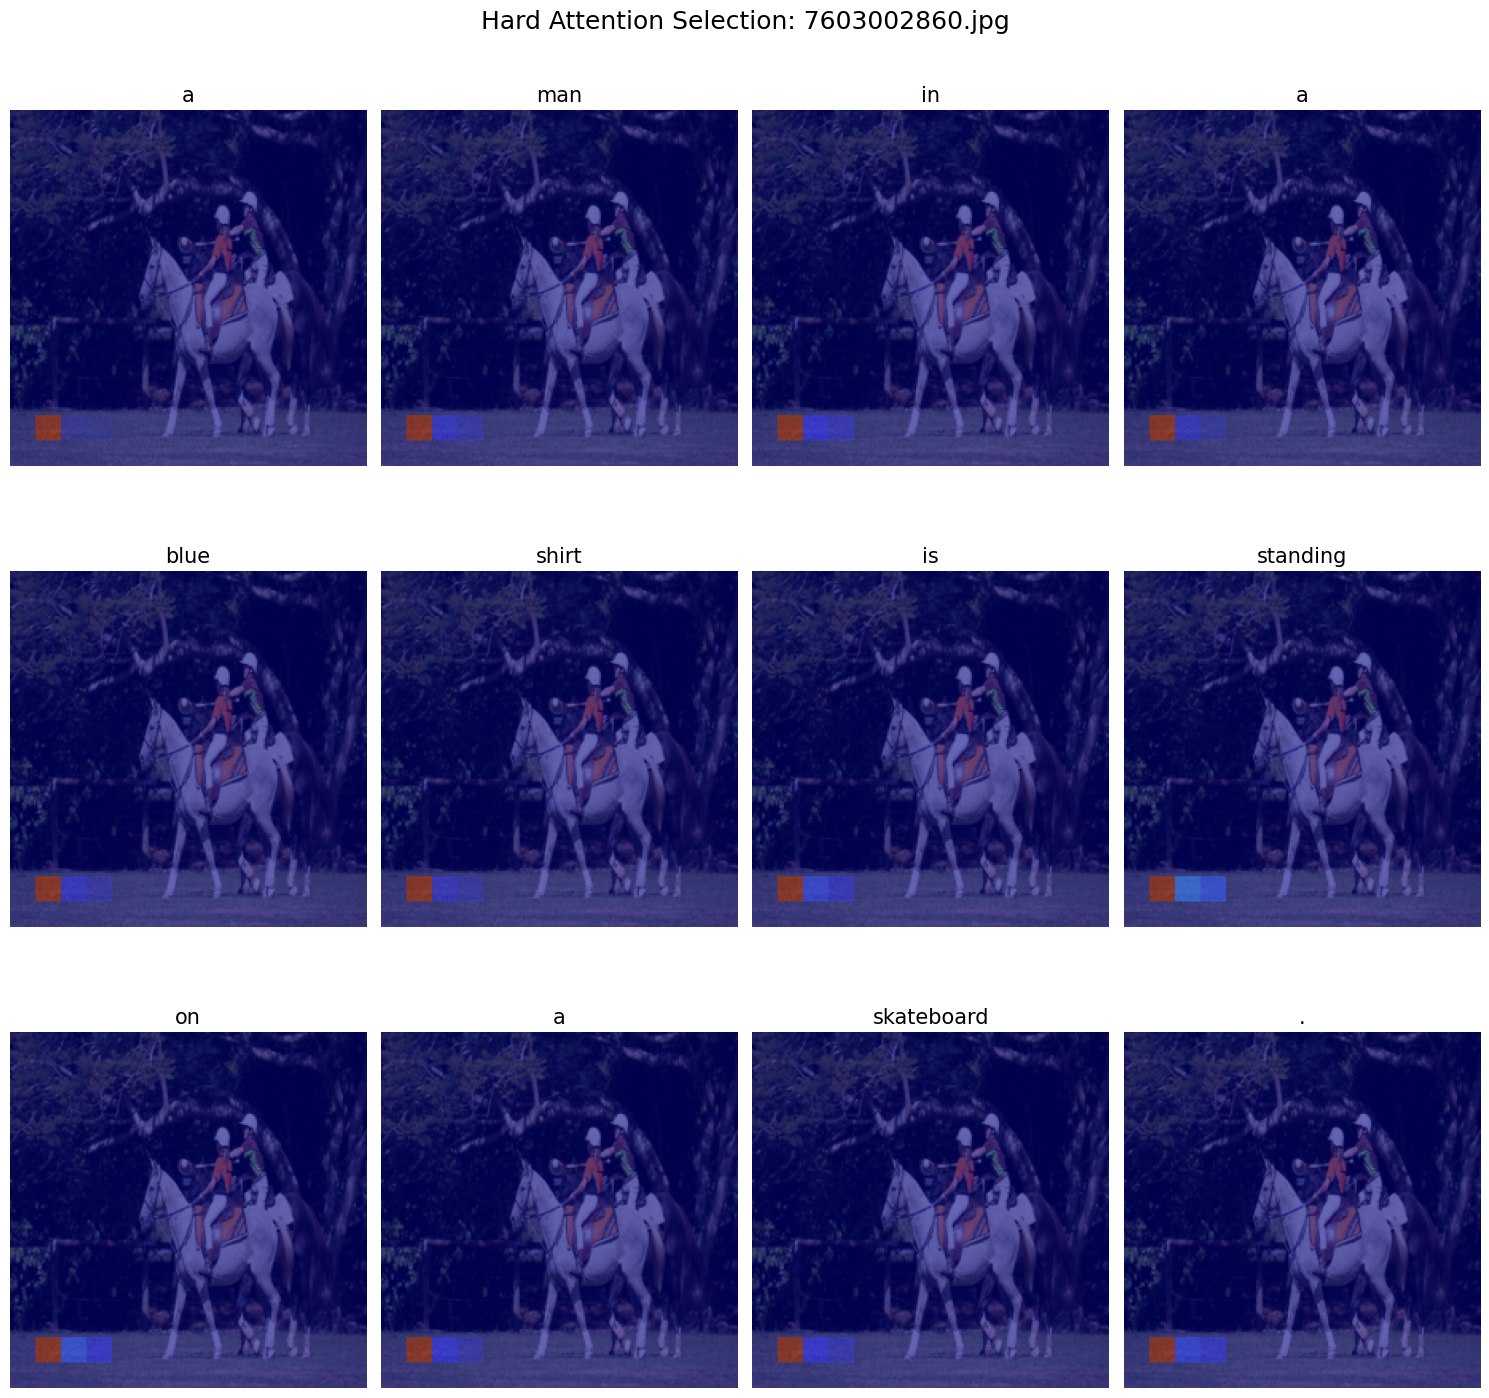

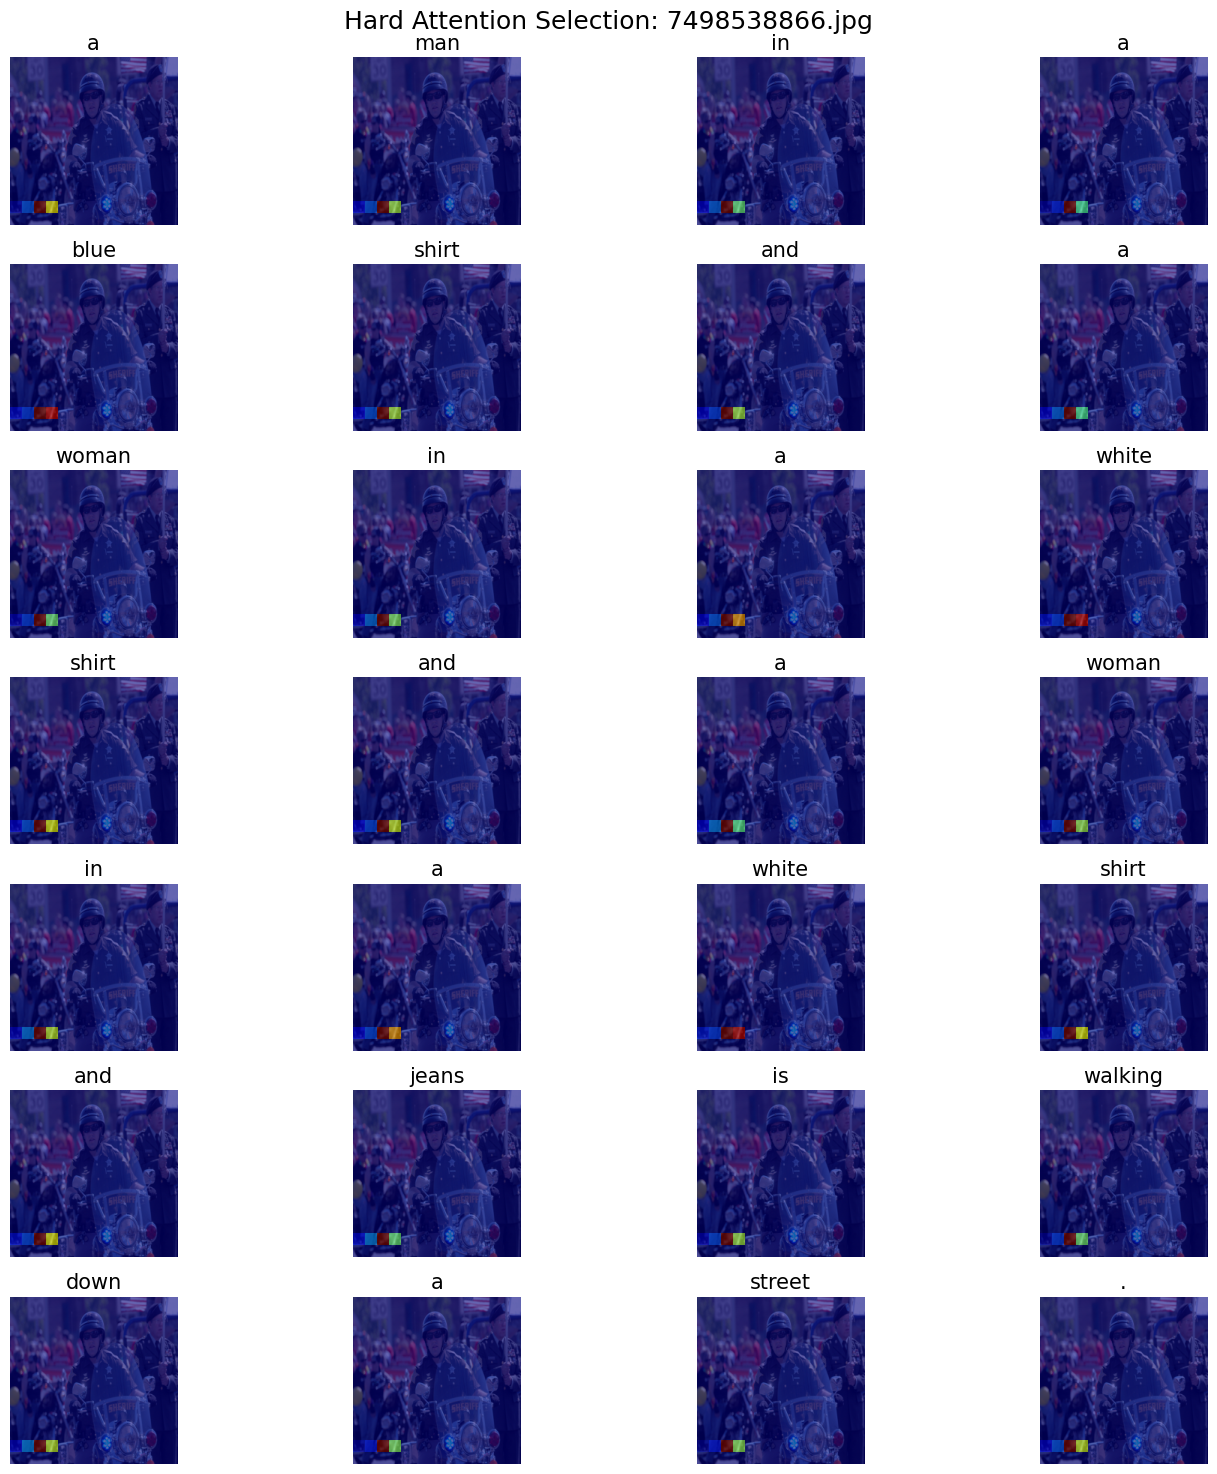

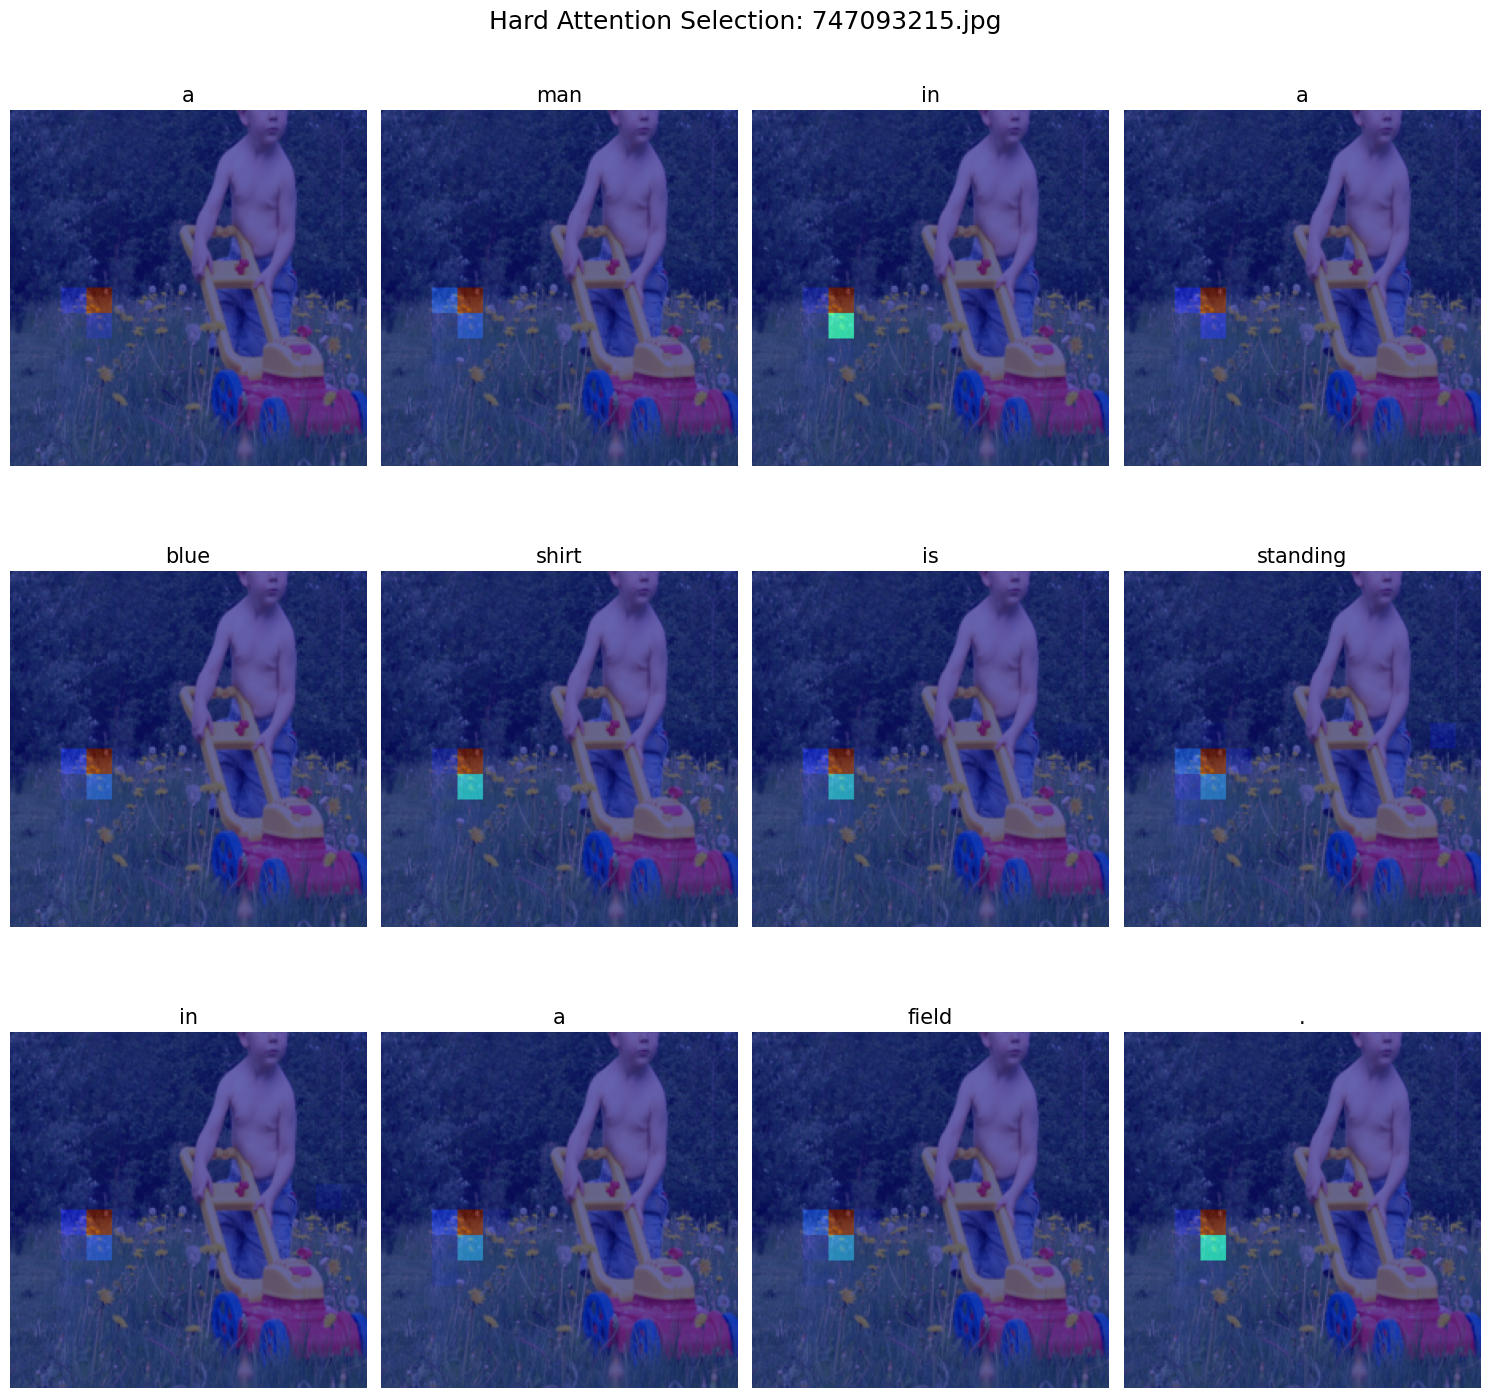

In [9]:
def visualize_hard_attention(encoder, decoder, dataset, num_images=3):
    encoder.eval()
    decoder.eval()
    
    with torch.no_grad():
        for i in range(num_images):
            idx = torch.randint(0, len(dataset.imgs), (1,)).item()
            img_id = dataset.imgs[idx]
            img, _, img_id = dataset[idx]
            
            img_show = img.clone()
            img_show[0] = img_show[0] * 0.229 + 0.485
            img_show[1] = img_show[1] * 0.224 + 0.456
            img_show[2] = img_show[2] * 0.225 + 0.406
            img_show = torch.clamp(img_show, 0, 1).permute(1, 2, 0).cpu().numpy()
            
            encoder_out = encoder(img.unsqueeze(0).to(device))
            encoder_out = encoder_out.view(1, -1, encoder_out.size(-1))
            h, c = decoder.init_hidden_state(encoder_out)
            
            word = torch.tensor([dataset.vocab.stoi["<SOS>"]]).to(device)
            pred_words = []
            alphas_list = []
            
            for _ in range(30):
                embeddings = decoder.embedding(word)
                attention_hard_encoding, alpha, _ = decoder.attention(encoder_out, h)
                gate = torch.cat([embeddings, attention_hard_encoding], dim=1)
                
                h, c = decoder.decode_step(gate, (h, c))
                preds = decoder.fc(h)
                
                predicted = preds.argmax(1)
                alpha_np = alpha.squeeze(0).view(14, 14).cpu().numpy()
                alphas_list.append(alpha_np)
                
                word_str = dataset.vocab.itos[predicted.item()]
                if word_str == "<EOS>":
                    break
                    
                pred_words.append(word_str)
                word = predicted
            
            fig = plt.figure(figsize=(15, 15))
            for t in range(len(pred_words)):
                ax = fig.add_subplot(int(np.ceil(len(pred_words)/4.)), 4, t+1)
                
                img_resized = np.array(Image.fromarray((img_show * 255).astype(np.uint8)).resize((224, 224)))
                ax.imshow(img_resized)
                
                alpha_resized = np.array(Image.fromarray(alphas_list[t]).resize((224, 224), Image.NEAREST))
                ax.imshow(alpha_resized, alpha=0.6, cmap='jet')
                ax.set_title(pred_words[t], fontsize=15)
                ax.axis('off')
                
            plt.suptitle(f"Hard Attention Selection: {img_id}", fontsize=18)
            plt.tight_layout()
            plt.show()

if decoder:
    visualize_hard_attention(encoder, decoder, test_ds, num_images=3)

In [10]:
import pickle

if decoder:
    checkpoint = {
        'encoder_state_dict': encoder.state_dict(),
        'decoder_state_dict': decoder.state_dict(),
        'vocab_stoi': train_ds.vocab.stoi,
        'vocab_itos': train_ds.vocab.itos,
        'embed_size': embed_size,
        'hidden_size': hidden_size,
        'attention_dim': attention_dim,
        'vocab_size': vocab_size
    }

    # Sauvegarder sous format .pkl
    file_name = 'show_attend_tell_hard_model.pkl'
    torch.save(checkpoint, file_name)

    print(f"Model checkpoint complete: '{file_name}'")

Model checkpoint complete: 'show_attend_tell_hard_model.pkl'
